# Bacterial Endocarditis Prediction from Prior ICD-9 History

This notebook is the **portfolio-facing version** of the project. The heavy implementation lives in `be_icd_portfolio_helpers.py`; the notebook keeps the design choices visible: cohort definition, leakage controls, temporal feature engineering, model training, and honest evaluation.

**Goal:** predict bacterial endocarditis (ICD-9 `4210`) from **prior** ICD-9 history in MIMIC-III. This is not a deployable clinical tool; it is a demonstration of clinical ML judgment under rare-outcome, leakage-prone conditions.

## Feature set

Use the True/False setting below to choose the model feature space.

In [14]:
from pathlib import Path

import pandas as pd
from IPython.display import display

REDUCED_FEATURES_CSV_PATH = Path("./top_reduced_BASE_features.csv")

# True  = train using features listed in top_reduced_BASE_features.csv
# False = train using the full candidate feature matrix
USE_REDUCED_FEATURE_SET = True

display(pd.DataFrame([{
    "USE_REDUCED_FEATURE_SET": USE_REDUCED_FEATURE_SET,
    "Feature set": "Reduced CSV feature list" if USE_REDUCED_FEATURE_SET else "Full candidate matrix",
    "Reduced feature CSV": str(REDUCED_FEATURES_CSV_PATH),
}]))

,USE_REDUCED_FEATURE_SET,Feature set,Reduced feature CSV
0,True,Reduced CSV feature list,top_reduced_BASE_features.csv


## 0. Setup

Imports are intentionally kept short. The helper module holds the bulky implementation so this notebook stays readable for portfolio review.

In [15]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

from IPython.display import display

import pandas as pd

from be_icd_portfolio_helpers import (
    add_event_index,
    add_rf_lasso_ensembles,
    shap_top_features_table,
    append_prior_history_clinical_features,
    assert_cohort_matches_freeze,
    balance_controls_to_case_admission_distribution,
    build_admission_level_history_tables,
    build_cohort_descriptive_table,
    build_metric_ci_table,
    build_temporal_diagnosis_feature_matrix,
    capture_environment_versions,
    clean_case_control_admission_features,
    configure_output_dirs,
    define_be_case_control_ids,
    initialize_analysis_state,
    load_mimic_tables,
    plot_calibration_all_models,
    plot_pooled_roc_all_models,
    plot_pr_curves_all_models,
    restrict_cases_to_pre_diagnosis_history,
    save_csv,
    shap_beeswarm,
    select_model_feature_space,
    summarize_sample_size,
    train_final_models_for_export,
    train_models_with_repeated_cv,
)

configure_output_dirs("model_outputs")

{'output_root': WindowsPath('model_outputs'),
 'figure_dir': WindowsPath('model_outputs/figures'),
 'data_dir': WindowsPath('model_outputs/data'),
 'feature_importance_dir': WindowsPath('model_outputs/data/feature_importance')}

## 1. Core design choices

These are the decisions a reviewer should focus on. The rest of the notebook applies them using self-explanatory helper calls.

In [16]:
MIMIC_DATA_DIR = "."
RANDOM_SEED = 42
BE_TARGET_ICD9_CODES = ["4210"]

# Leakage controls
NEAR_INDEX_VALVE_PROCEDURE_SCRUB_DAYS = 42
NEAR_INDEX_WORKUP_SCRUB_DAYS = 42

SHAP_BACKGROUND_SAMPLE_SIZE = 200
SHAP_EXPLANATION_SAMPLE_SIZE = 300

analysis_config_summary = pd.DataFrame([
    {"Setting": "Target ICD-9 code", "Value": ", ".join(BE_TARGET_ICD9_CODES)},
    {"Setting": "Use reduced feature set", "Value": USE_REDUCED_FEATURE_SET},
    {"Setting": "Random seed", "Value": RANDOM_SEED},
])

display(analysis_config_summary)

,Setting,Value
0,Target ICD-9 code,4210
1,Use reduced feature set,True
2,Random seed,42


## 2. Load MIMIC-III tables

Raw MIMIC files are not included in the repository because access is credentialed. Run this locally in the directory containing the required CSV/XLSX files.

In [17]:
mimic_tables = load_mimic_tables(MIMIC_DATA_DIR)
pipeline_config, setup_summary = initialize_analysis_state(
    mimic_tables,
    random_seed=RANDOM_SEED,
    valve_proc_gap_days=NEAR_INDEX_VALVE_PROCEDURE_SCRUB_DAYS,
    workup_gap_days=NEAR_INDEX_WORKUP_SCRUB_DAYS,
)
pipeline_config["target_icd9_codes"] = BE_TARGET_ICD9_CODES

display(setup_summary)


,Item,Value
0,Diagnosis-code universe,"6,985 codes"
1,Procedure-code universe,"2,009 codes"
2,Valve timing scrub,case admissions within 42 days of index
3,Duke/workup scrub,case admissions within 42 days of index
4,Random seed,42


## 3. Define cases and controls

Cases are patients with ICD-9 `4210`. Controls exclude any patient with BE ICD code or admission text indicating bacterial endocarditis.

In [18]:
cohort_definition, mimic_tables = define_be_case_control_ids(mimic_tables, pipeline_config)

case_control_summary = pd.DataFrame([
    {"Cohort": "BE cases", "Patients": len(cohort_definition["disease_subject_ids"])},
    {"Cohort": "Candidate controls", "Patients": len(cohort_definition["control_subject_ids"])},
    {"Cohort": "BE index admissions", "Patients": len(cohort_definition["disease_hadm_ids"])},
])
display(case_control_summary)


,Cohort,Patients
0,BE cases,336
1,Candidate controls,46181
2,BE index admissions,385


## 4. Build admission-level histories

Diagnosis and procedure codes are compressed into per-admission lists. The target diagnosis code is dropped from diagnosis features so the label cannot directly leak into the model.

In [19]:
case_admission_history, control_admission_history, diagnosis_codes_for_feature_engineering = build_admission_level_history_tables(
    mimic_tables, cohort_definition, pipeline_config
)

admission_history_summary = pd.DataFrame([
    {"Cohort": "BE cases", "Admission rows": case_admission_history.shape[0]},
    {"Cohort": "Candidate controls", "Admission rows": control_admission_history.shape[0]},
])
display(admission_history_summary)


,Cohort,Admission rows
0,BE cases,676
1,Candidate controls,58297


## 5. Leakage controls: prior history only + near-index scrubs

For cases, only admissions before the first BE admission are retained. Near-index valve-treatment codes and Duke/workup/presentation codes are scrubbed from case histories to reduce reverse-causation leakage.

In [20]:
case_admission_history, leakage_summary, case_prior_admission_counts = restrict_cases_to_pre_diagnosis_history(
    case_admission_history,
    cohort_definition["disease_hadm_ids"],
    pipeline_config,
)
control_admission_history = add_event_index(control_admission_history)

display(leakage_summary)


,Check,Value
0,Case admissions retained before BE index,153 rows
1,Cases with 1 prior admission,39
2,Cases with 2+ prior admissions,34
3,Valve/treatment code occurrences scrubbed,0
4,Duke/workup code occurrences scrubbed,0


## 6. Control balancing and cohort freeze

Controls are subsampled so their admission-count distribution is closer to the case cohort. The selected cohort is frozen to `model_cohort_ids.csv` for reproducibility.

In [21]:
(
    selected_control_subject_ids,
    control_admission_history,
    all_control_admission_counts,
    selected_control_admission_counts,
    cohort_design_summary,
    cohort_freeze_summary,
) = balance_controls_to_case_admission_distribution(
    control_admission_history,
    case_prior_admission_counts,
    cohort_definition["disease_subject_ids"],
    random_seed=RANDOM_SEED,
    cohort_path="model_cohort_ids.csv",
)
cohort_definition["control_subject_ids"] = selected_control_subject_ids

display(cohort_design_summary)
display(cohort_freeze_summary)
display(assert_cohort_matches_freeze(cohort_definition["disease_subject_ids"], cohort_definition["control_subject_ids"]))


,Item,Value
0,Control balancing,reused frozen cohort
1,Control admission rows,"30,862"
2,Control patients,"19,685"


,Status,Path,Cases,Controls
0,Cohort freeze present,model_cohort_ids.csv,336,19685


,Guard,Cases,Controls
0,Frozen cohort matches notebook cohort,336,19685


## 7. Clean admission features

LOS and age are computed, invalid rows are dropped, and identifiers/outcome-adjacent columns are removed before patient-level aggregation.

In [22]:
case_modeling_admissions, control_modeling_admissions, preprocess_summary = clean_case_control_admission_features(
    case_admission_history, control_admission_history
)
display(preprocess_summary)


,Cohort,Invalid rows dropped,Leaky columns removed
0,BE cases,0,10
1,Controls,2944,10


## 8. Temporal diagnosis features

Each ICD-9 diagnosis is prefixed by admission recency (`T-1`, `T-2`, ...). Procedure one-hots are intentionally excluded for transportability; procedures are still used upstream for leakage scrubbing.

In [23]:
(
    model_feature_matrix,
    target_labels,
    diagnosis_temporal_binarizer,
    modeling_subject_ids,
    case_temporal_diagnosis_prevalence,
    control_temporal_diagnosis_prevalence,
    patient_level_feature_frame,
    temporal_matrix_summary,
) = build_temporal_diagnosis_feature_matrix(
    case_modeling_admissions,
    control_modeling_admissions,
    cohort_definition["disease_subject_ids"],
    cohort_definition["control_subject_ids"],
)

display(temporal_matrix_summary)


,Metric,Value
0,Patient-level matrix shape,"(17053, 11611)"
1,Target shape,"(17053,)"
2,BE cases,73
3,Controls,16980
4,Procedure one-hots,Excluded for eICU transportability


## 9. Add prior-history clinical features and choose feature space

The pipeline builds the candidate feature matrix, then uses `USE_REDUCED_FEATURE_SET` to choose reduced CSV features or the full matrix.

In [24]:
candidate_feature_matrix, clinical_feature_audit_table, engineered_feature_names, engineered_feature_summary = append_prior_history_clinical_features(
    model_feature_matrix,
    mimic_tables,
    diagnosis_codes_for_feature_engineering,
    cohort_definition,
    modeling_subject_ids,
    pipeline_config["patient_gender"],
    excluded_features=set(),
)

candidate_feature_names = (
    [f"DX_{feature_name}" for feature_name in diagnosis_temporal_binarizer.classes_]
    + ["LOS_DAYS", "Age"]
    + engineered_feature_names
)

reduced_features = pd.read_csv(REDUCED_FEATURES_CSV_PATH)

model_feature_matrix, model_feature_names, feature_selection_summary = select_model_feature_space(
    candidate_feature_matrix,
    candidate_feature_names,
    reduced_features,
    use_reduced_feature_set=USE_REDUCED_FEATURE_SET,
)

display(engineered_feature_summary)
display(feature_selection_summary)

,Item,Value
0,Excluded generic utilization features,"prior_admit_count_1y, prior_total_icd_mentions_1y"
1,Added engineered features,10
2,Feature window,index-395d to index-0d + ever-prior flags
3,Final sparse matrix shape,"(17053, 11621)"


,Item,Value
0,Feature set,Reduced CSV feature list
1,Features requested by CSV,102
2,Features matched,72
3,Features missing,30
4,Final matrix shape,"(17053, 72)"


## 10. Cohort descriptives and sample size

This is the quick Table-1-style sanity check plus the events-per-feature accounting that sets expectations for rare-outcome model variance.

In [25]:
cohort_descriptive_table, case_demographics_table, control_demographics_table = build_cohort_descriptive_table(
    cohort_definition["disease_subject_ids"],
    cohort_definition["control_subject_ids"],
    pipeline_config["patient_gender"],
    case_modeling_admissions,
    control_modeling_admissions,
)
save_csv(cohort_descriptive_table, "cohort_descriptive_table.csv", index=False)

display(cohort_descriptive_table.assign(p_value=lambda df: df["p_value"].map(lambda p: f"{p:.4f}")))
display(summarize_sample_size(model_feature_matrix, target_labels))


,Characteristic,Positive class / BE cases,Negative class / Controls,p_value,Significance
0,"Female, n (%)",108 (32.1%),8694 (44.2%),0.0000,***
1,"Male, n (%)",228 (67.9%),10991 (55.8%),0.0000,***
2,"Age, median [IQR]",68.0 [54.0-77.0],66.0 [53.0-78.0],0.9895,ns
3,"LOS (days), median [IQR]",13.0 [7.0-24.0],9.0 [5.0-15.0],0.0018,**


,Metric,Value
0,Cases (BE),73
1,Controls,"16,980"
2,Prevalence,0.428%
3,Features,72
4,Events per feature,1.014


## 11. Repeated cross-validation

Controls are split into non-overlapping partitions; each partition is paired with all BE cases and evaluated with 5-fold stratified CV. Scaling, χ² scores, and oversampling happen inside each fold to avoid leakage.

In [26]:
cross_validation_results = train_models_with_repeated_cv(
    model_feature_matrix,
    target_labels,
    modeling_subject_ids,
    cohort_definition["disease_subject_ids"],
    cohort_definition["control_subject_ids"],
    model_feature_names,
    control_sample_size=min(2800, len(cohort_definition["control_subject_ids"])),
    n_splits=5,
    shap_bg_size=SHAP_BACKGROUND_SAMPLE_SIZE,
    shap_test_size=SHAP_EXPLANATION_SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
)

save_csv(cross_validation_results["summary_metrics_df"], "model_summary_metrics.csv", index=False)
save_csv(cross_validation_results["fold_metrics_df"], "model_fold_metrics.csv", index=False)
display(cross_validation_results["summary_metrics_df"])

c:\Users\dmenz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\dmenz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\dmenz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

,Model,AUC_mean,AUC_std,Sens_mean,Sens_std,Spec_mean,Spec_std,Threshold_mean,Threshold_std
0,Lasso,0.7598,0.0636,0.7218,0.1246,0.7883,0.0666,0.0692,0.0237
1,RandomForest,0.7573,0.0686,0.7732,0.1452,0.7257,0.1232,0.0805,0.0281
2,XGBoost,0.6898,0.0606,0.6162,0.1600,0.7530,0.1514,0.3241,0.1417


## 12. Ensemble comparison

Random Forest and Lasso are combined with a soft-vote and a row-level stacked logistic meta-learner, then evaluated against the same pooled out-of-fold predictions.

In [27]:
model_predictions, ensemble_compare_df = add_rf_lasso_ensembles(cross_validation_results["model_predictions"])
save_csv(ensemble_compare_df, "ensemble_vs_base_models.csv", index=False)
display(ensemble_compare_df)


,Model,ROC_AUC,Average_Precision
4,Stack(RF+Lasso),0.7688,0.1518
3,SoftVote(RF+Lasso),0.7696,0.1518
2,Lasso,0.7543,0.1449
0,RandomForest,0.7504,0.1362
1,XGBoost,0.6855,0.1114


## 13. Headline discrimination and precision-recall

AUROC can be flattering under rare outcomes; average precision/PR curves show the more clinically relevant precision-recall tradeoff.

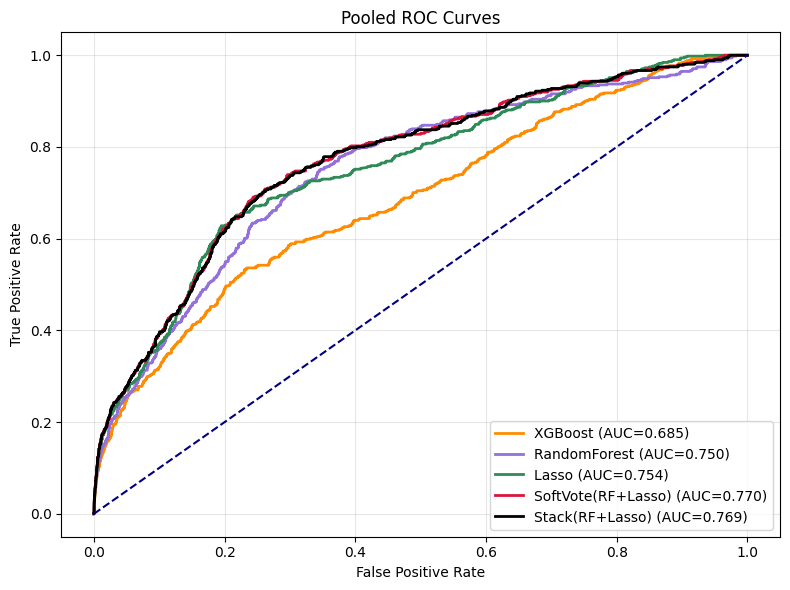

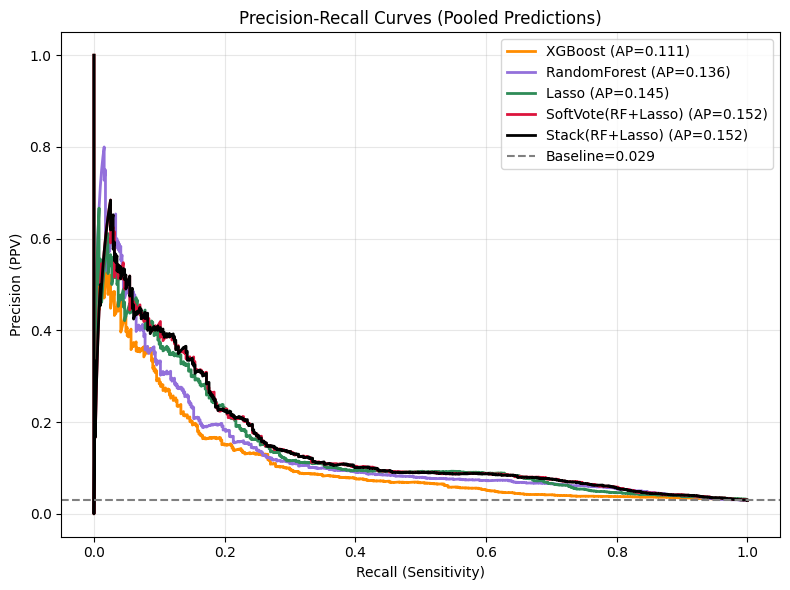

,Model,Pooled_ROC_AUC
3,SoftVote(RF+Lasso),0.769570
4,Stack(RF+Lasso),0.768833
2,Lasso,0.754330
1,RandomForest,0.750447
0,XGBoost,0.685479


,Model,Average_Precision,Baseline_prevalence
4,Stack(RF+Lasso),0.151817,0.029348
3,SoftVote(RF+Lasso),0.151806,0.029348
2,Lasso,0.144873,0.029348
1,RandomForest,0.136203,0.029348
0,XGBoost,0.111404,0.029348


In [28]:
roc_auc_table = plot_pooled_roc_all_models(model_predictions, "final_roc_curve_all_models.png")
precision_recall_table = plot_pr_curves_all_models(model_predictions, "pr_curves_all_models.png")

save_csv(roc_auc_table, "aggregated_roc_auc_by_model.csv", index=False)
save_csv(precision_recall_table, "aggregated_pr_ap_by_model.csv", index=False)

display(roc_auc_table)
display(precision_recall_table)


## 14. Interpretability: SHAP beeswarms

SHAP is used as a model-audit view, not as a causal claim. The most useful plot for portfolio review is usually one strong model plus one sensitivity model, rather than every possible diagnostic.

c:\Users\dmenz\Downloads\BIOE5860\be_icd_portfolio_helpers.py:1505: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


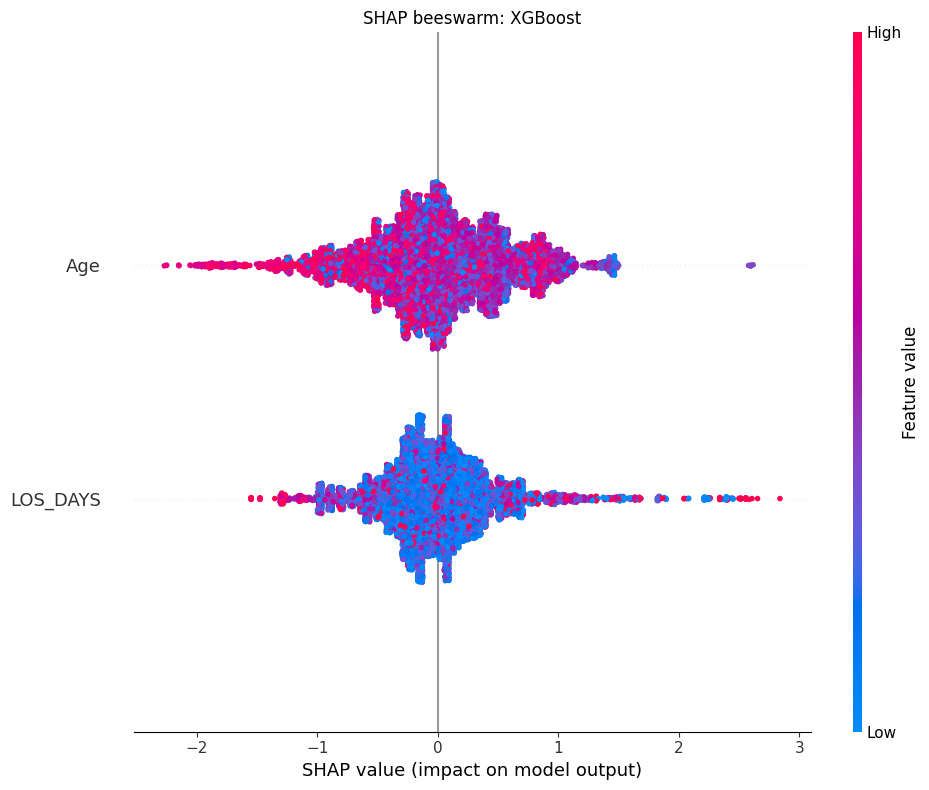

c:\Users\dmenz\Downloads\BIOE5860\be_icd_portfolio_helpers.py:1505: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\dmenz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
c:\Users\dmenz\Downloads\BIOE5860\be_icd_portfolio_helpers.py:1515: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [ ]:
final_test_feature_frame = cross_validation_results["final_X_te_df"]
final_shap_values_by_model = cross_validation_results["final_shap_dfs"]
feature_importance_table = cross_validation_results["master_feat_df"]

save_csv(feature_importance_table, "feature_importance_master.csv", index=False)

_ = shap_beeswarm(final_shap_values_by_model["RandomForest"], final_test_feature_frame, "Random Forest", "shap_beeswarm_random_forest.png")
rf_top_features = shap_top_features_table(final_shap_values_by_model["RandomForest"], "Random Forest")
save_csv(rf_top_features, "shap_top_features_random_forest.csv", index=False)
display(rf_top_features)

_ = shap_beeswarm(final_shap_values_by_model["Lasso"], final_test_feature_frame, "Lasso", "shap_beeswarm_lasso.png")
lasso_top_features = shap_top_features_table(final_shap_values_by_model["Lasso"], "Lasso")
save_csv(lasso_top_features, "shap_top_features_lasso.csv", index=False)
display(lasso_top_features)


## 15. Calibration and uncertainty

Calibration/Brier score and bootstrap confidence intervals provide a more honest view than a single headline AUC.

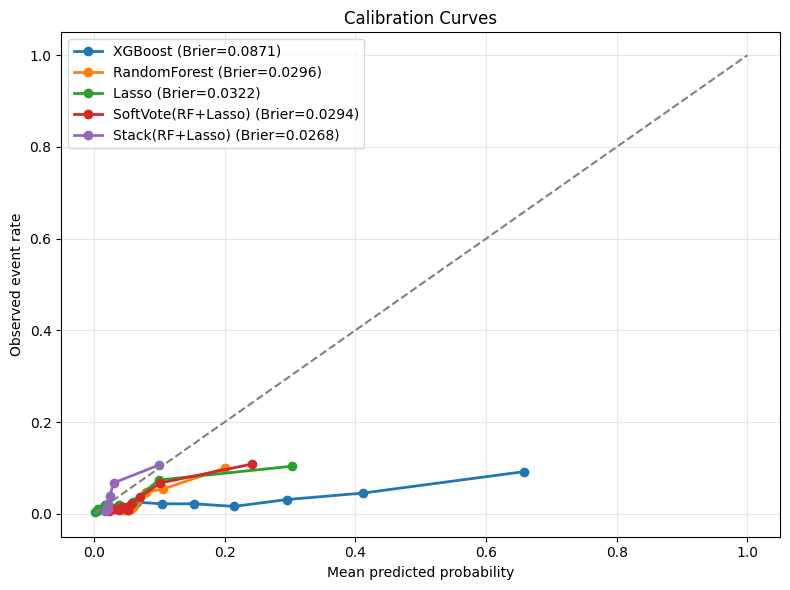

,Model,Brier
4,Stack(RF+Lasso),0.026807
3,SoftVote(RF+Lasso),0.029422
1,RandomForest,0.029591
2,Lasso,0.032207
0,XGBoost,0.087147


,Model,ROC_AUC,ROC_AUC_95CI,Average_Precision,AP_95CI
4,Stack(RF+Lasso),0.768833,0.746-0.789,0.151817,0.124-0.188
3,SoftVote(RF+Lasso),0.769570,0.747-0.790,0.151806,0.124-0.188
2,Lasso,0.754330,0.732-0.776,0.144873,0.118-0.182
1,RandomForest,0.750447,0.727-0.771,0.136203,0.111-0.168
0,XGBoost,0.685479,0.660-0.709,0.111404,0.090-0.141


In [ ]:
calibration_table = plot_calibration_all_models(model_predictions, "calibration_all_models.png")
metric_confidence_interval_table = build_metric_ci_table(model_predictions, n_boot=1000, seed=RANDOM_SEED)

save_csv(calibration_table, "calibration_brier_by_model.csv", index=False)
save_csv(metric_confidence_interval_table, "pooled_metric_bootstrap_ci.csv", index=False)

display(calibration_table)
display(metric_confidence_interval_table)


## 16. Optional export

This trains final scoring artifacts on the currently selected feature matrix. It is optional for the portfolio; the main value of the repo is the cohort design, leakage controls, feature engineering, and evaluation discipline.

In [ ]:
final_model_export_summary = train_final_models_for_export(
    model_feature_matrix,
    target_labels,
    model_feature_names,
    export_dir="model_outputs/export",
    random_seed=RANDOM_SEED,
)
display(final_model_export_summary)


,Artifact,Value
0,Final models,"XGBoost, RandomForest, Lasso"
1,Scaler,scaler_maxabs.joblib
2,Feature names,feature_names.json
3,Feature count,72


## Limitations

- This is a case-control research prototype, not a deployed clinical model.
- MIMIC coding practices and ICU population structure may not generalize cleanly.
- Positive class size is small, so fold-to-fold variance and AP uncertainty matter.
- The strongest contribution is the leakage-aware design and transparent evaluation, not a claim that ICD history alone is sufficient for clinical decision-making.